# Phase 4 — Lightweight CNN Baseline

Reviewer-requested comparison with a lightweight ML-based detector.

**Architecture:** 1D CNN on log-magnitude PSD (2001 frequency bins)
- `Conv1d(1→16, k=11)` → `ReLU` → `Conv1d(16→32, k=7)` → `ReLU` → `GlobalAvgPool1d`
- `Linear(32→64)` → `ReLU` → `Dropout(0.3)` → `Linear(64→1)` → sigmoid
- ~6 K parameters — genuinely lightweight

**Training:** 5-fold stratified cross-validation on segment indices (no chunk-level leakage).  
**Evaluation:** out-of-fold (OOF) predictions → unbiased segment-level ROC / Pd / AUC.

**Stress tests:** best fold model evaluated on amplitude-scaled and duty-cycle-masked data.  
Combined plots load `results/review_1/aed_stress_*.csv` from phase3_aed_baseline.ipynb.

**Estimated runtime:**
- PSD loading: ~3 min
- 5-fold CV training (20 epochs each, GPU): ~5–10 min
- Stress tests (CNN inference only): ~10 min
- Total: ~20–25 min

All outputs → `results/review_1/`

In [1]:
import os
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
from pathlib import Path
from dotenv import load_dotenv
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import StratifiedKFold
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

ROOT = Path().resolve().parents[2]
sys.path.insert(0, str(ROOT / "src"))

from rfml_uav.drone_rf.consts import BUI, FS_HZ
from rfml_uav.drone_rf.utils import get_segment_count, get_binary_label

load_dotenv()
CHUNKED_PATH = Path(os.getenv("DATA_PATH")) / "chunked"
OUT = ROOT / "results" / "review_1"
OUT.mkdir(parents=True, exist_ok=True)

DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BG_BUI     = "00000"
FIXED_PFA  = 0.05
N_CHUNK    = 4000           # samples per chunk
N_FREQ     = N_CHUNK // 2 + 1  # rfft output bins = 2001
N_FOLDS    = 5
N_EPOCHS   = 20
BATCH_SIZE = 256
LR         = 1e-3

SIGNAL_BUIS = [b for b in BUI if get_binary_label(b) == 1]
NOISE_BUIS  = [b for b in BUI if get_binary_label(b) == 0]

CNN_COLOR  = "#e377c2"
CNN_MARKER = "v"

print(f"ROOT         : {ROOT}")
print(f"CHUNKED_PATH : {CHUNKED_PATH}")
print(f"Device       : {DEVICE}")
print(f"N_FREQ       : {N_FREQ}")
print(f"Signal BUIs  : {SIGNAL_BUIS}")
print(f"Noise BUIs   : {NOISE_BUIS}")

ROOT         : /home/ivan/work/ml/rfml-uav
CHUNKED_PATH : /home/ivan/work/ml/rfml-uav/data/drone-rf/chunked
Device       : cuda
N_FREQ       : 2001
Signal BUIs  : ['10000', '10001', '10010', '10011', '10100', '10101', '10110', '10111', '11000']
Noise BUIs   : ['00000']


---
## PSD feature extraction + data loading

Feature: log-magnitude PSD `log1p(|rfft(x)|)`, shape `(2001,)` per chunk.  
Using `np.fft.rfft(chunks, axis=1)` to batch the FFT over all chunks in a file at once.

Stored as `segment_data`: list of dicts with keys `{bui, seg, label, psd}` where
`psd` is float32 of shape `(N_chunks, 2001)`. Estimated total RAM: ~550 MB.

In [2]:
def compute_psd(chunks):
    """Batch log-magnitude PSD. chunks: ndarray (N, N_CHUNK). Returns float32 (N, N_FREQ)."""
    return np.log1p(np.abs(np.fft.rfft(chunks, axis=1))).astype(np.float32)


def duration_constrained_score(scores, min_duration=0.10):
    k = max(1, int(np.ceil(min_duration / (N_CHUNK / FS_HZ))))
    if len(scores) <= k:
        return float(np.mean(scores))
    return float(np.mean(np.sort(scores)[-k:]))

In [3]:
print("Loading PSD features for all segments...")
segment_data = []
total_chunks = 0
all_buis = [(b, 1) for b in SIGNAL_BUIS] + [(b, 0) for b in NOISE_BUIS]

for bui, label in tqdm(all_buis):
    for seg in range(get_segment_count(bui)):
        files = sorted(glob(str(CHUNKED_PATH / f"{bui}*_{seg}.npz")))
        if not files:
            continue
        psd_list = []
        for fp in files:
            chunks = np.load(fp)["arr_0"]  # (N, N_CHUNK), float64
            psd_list.append(compute_psd(chunks))
        psd_arr = np.concatenate(psd_list, axis=0)  # (total_N, N_FREQ), float32
        segment_data.append({"bui": bui, "seg": seg, "label": label, "psd": psd_arr})
        total_chunks += len(psd_arr)

n_segs    = len(segment_data)
n_signal  = sum(1 for d in segment_data if d["label"] == 1)
n_noise   = sum(1 for d in segment_data if d["label"] == 0)
total_mb  = sum(d["psd"].nbytes for d in segment_data) / 1e6

print(f"\nLoaded {n_segs} segments: {n_signal} signal, {n_noise} background")
print(f"Total chunks: {total_chunks:,}")
print(f"Total PSD RAM: {total_mb:.0f} MB")

Loading PSD features for all segments...


100%|██████████| 10/10 [00:44<00:00,  4.50s/it]


Loaded 227 segments: 186 signal, 41 background
Total chunks: 1,349,460
Total PSD RAM: 10801 MB


---
## Model and training utilities

`LightweightCNN` takes input `(B, 1, 2001)` and outputs `(B,)` logits.  
BCEWithLogitsLoss for training; sigmoid applied externally for probabilities.

In [4]:
class LightweightCNN(nn.Module):
    def __init__(self, n_freq=N_FREQ):
        super().__init__()
        self.conv1 = nn.Conv1d(1,  16, kernel_size=11, padding=5)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=7,  padding=3)
        self.gap   = nn.AdaptiveAvgPool1d(1)
        self.fc1   = nn.Linear(32, 64)
        self.drop  = nn.Dropout(0.3)
        self.fc2   = nn.Linear(64, 1)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.gap(x).squeeze(-1)
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        return self.fc2(x).squeeze(-1)  # (B,) logits


n_params = sum(p.numel() for p in LightweightCNN().parameters())
print(f"LightweightCNN: {n_params:,} parameters")


def train_fold(X_train, y_train, device, n_epochs=N_EPOCHS, batch_size=BATCH_SIZE, lr=LR):
    """Train LightweightCNN on (N, n_freq) PSD features with binary labels."""
    model = LightweightCNN(n_freq=X_train.shape[1]).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    dataset = torch.utils.data.TensorDataset(
        torch.from_numpy(X_train).unsqueeze(1),
        torch.from_numpy(y_train.astype(np.float32)),
    )
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

    for epoch in range(n_epochs):
        model.train()
        total_loss = 0.0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        if (epoch + 1) % 5 == 0:
            print(f"    epoch {epoch+1:2d}/{n_epochs}  loss={total_loss / len(loader):.4f}")
    return model


def eval_fold(model, segs, device, batch_size=BATCH_SIZE, return_chunks=False):
    """Segment-level evaluation with batched inference to avoid GPU OOM.

    If return_chunks=True, also returns per_seg_chunk_probs: a list of lists,
    one list of chunk probabilities per segment (same order as segs).
    """
    model.eval()
    seg_scores, seg_labels = [], []
    per_seg_chunk_probs = []
    with torch.no_grad():
        for d in segs:
            psd = d["psd"]
            chunk_probs = []
            for i in range(0, len(psd), batch_size):
                batch  = psd[i:i + batch_size]
                x      = torch.from_numpy(batch).unsqueeze(1).to(device)
                logits = model(x).cpu().numpy()
                probs  = (1.0 / (1.0 + np.exp(-logits))).tolist()
                chunk_probs.extend(probs)
            seg_scores.append(duration_constrained_score(chunk_probs))
            seg_labels.append(d["label"])
            if return_chunks:
                per_seg_chunk_probs.append(chunk_probs)
    if return_chunks:
        return np.array(seg_scores), np.array(seg_labels), per_seg_chunk_probs
    return np.array(seg_scores), np.array(seg_labels)


def evaluate_cnn_transform(transform_fn, model, device, desc=""):
    """CNN-only segment-level evaluation with an arbitrary chunk transform.
    Streams one .npz file at a time; inference is batched to avoid GPU OOM.
    """
    model.eval()
    seg_scores, seg_labels = [], []
    all_buis = [(b, 1) for b in SIGNAL_BUIS] + [(b, 0) for b in NOISE_BUIS]
    with torch.no_grad():
        for bui, label in tqdm(all_buis, desc=desc):
            for seg in range(get_segment_count(bui)):
                files = sorted(glob(str(CHUNKED_PATH / f"{bui}*_{seg}.npz")))
                if not files:
                    continue
                chunk_probs = []
                for fp in files:
                    raw    = np.load(fp)["arr_0"]
                    chunks = transform_fn(raw) if label == 1 else raw
                    psd    = compute_psd(chunks)
                    for i in range(0, len(psd), BATCH_SIZE):
                        batch  = psd[i:i + BATCH_SIZE]
                        x      = torch.from_numpy(batch).unsqueeze(1).to(device)
                        logits = model(x).cpu().numpy()
                        probs  = (1.0 / (1.0 + np.exp(-logits))).tolist()
                        chunk_probs.extend(probs)
                seg_scores.append(duration_constrained_score(chunk_probs))
                seg_labels.append(label)
    return np.array(seg_scores), np.array(seg_labels)

LightweightCNN: 5,985 parameters


---
## 5-fold stratified cross-validation

Folds are split at the **segment level** (not chunk level) to prevent data leakage.
Stratified by binary label to maintain class ratio across folds.

OOF (out-of-fold) predictions give an unbiased estimate of segment-level Pd / AUC.

**Expected runtime: ~5–10 min (GPU)**

In [5]:
all_seg_labels  = np.array([d["label"] for d in segment_data])
all_seg_indices = np.arange(len(segment_data))
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

oof_scores      = np.zeros(len(segment_data))
oof_chunk_probs = [None] * len(segment_data)  # per-segment chunk probs, used in phase5
fold_aucs   = []
fold_models = []
best_auc    = -1.0
best_model  = None

t_cv_start = time.perf_counter()

for fold, (train_idx, test_idx) in enumerate(
        skf.split(all_seg_indices, all_seg_labels)):

    print(f"\n--- Fold {fold + 1}/{N_FOLDS} ---")

    # Gather training chunks
    X_list, y_list = [], []
    for i in train_idx:
        d = segment_data[i]
        X_list.append(d["psd"])
        y_list.extend([float(d["label"])] * len(d["psd"]))
    X_train = np.concatenate(X_list, axis=0)
    y_train = np.array(y_list)
    del X_list, y_list  # free before GPU training
    print(f"  Train: {len(train_idx)} segs, {len(X_train):,} chunks"
          f"  (pos={y_train.sum():.0f}, neg={(1-y_train).sum():.0f})")

    model = train_fold(X_train, y_train, DEVICE)
    del X_train, y_train  # free training data
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    fold_models.append(model)

    # Evaluate on held-out segments (batched to avoid GPU OOM)
    test_segs = [segment_data[i] for i in test_idx]
    fold_scores, _, fold_chunk_probs = eval_fold(model, test_segs, DEVICE, return_chunks=True)
    test_labels = all_seg_labels[test_idx]

    for k, idx in enumerate(test_idx):
        oof_scores[idx]      = fold_scores[k]
        oof_chunk_probs[idx] = fold_chunk_probs[k]

    fpr, tpr, _ = roc_curve(test_labels, fold_scores)
    fold_auc = float(auc(fpr, tpr))
    fold_aucs.append(fold_auc)
    ok  = np.where(fpr <= FIXED_PFA)[0]
    ipd = ok[np.argmax(tpr[ok])] if len(ok) else np.argmin(fpr)
    print(f"  Val AUC={fold_auc:.3f}  Pd@Pfa={FIXED_PFA}={tpr[ipd]:.3f}")

    if fold_auc > best_auc:
        best_auc   = fold_auc
        best_model = model
        best_fold  = fold + 1

t_cv = time.perf_counter() - t_cv_start
print(f"\nCV finished in {t_cv/60:.1f} min")
print(f"Fold AUCs: {[f'{a:.3f}' for a in fold_aucs]}")
print(f"Mean AUC: {np.mean(fold_aucs):.3f} ± {np.std(fold_aucs):.3f}")
print(f"Best fold: {best_fold} (AUC={best_auc:.3f})")

# Save OOF scores so phase5_combined_roc.ipynb can load them without re-training
all_oof_chunk_probs  = np.concatenate([np.array(p) for p in oof_chunk_probs])
all_oof_chunk_labels = np.concatenate(
    [np.full(len(oof_chunk_probs[i]), segment_data[i]["label"])
     for i in range(len(segment_data))])
np.save(OUT / "cnn_oof_seg_scores.npy",   oof_scores)
np.save(OUT / "cnn_oof_seg_labels.npy",   all_seg_labels)
np.save(OUT / "cnn_oof_chunk_probs.npy",  all_oof_chunk_probs)
np.save(OUT / "cnn_oof_chunk_labels.npy", all_oof_chunk_labels)
print(f"\nSaved OOF scores → results/review_1/")
print(f"  Segments : {len(oof_scores)}")
print(f"  Chunks   : {len(all_oof_chunk_probs):,}")


--- Fold 1/5 ---
  Train: 181 segs, 1,062,866 chunks  (pos=897866, neg=165000)
    epoch  5/20  loss=0.3117
    epoch 10/20  loss=0.2365
    epoch 15/20  loss=0.2085
    epoch 20/20  loss=0.1987
  Val AUC=1.000  Pd@Pfa=0.05=1.000

--- Fold 2/5 ---
  Train: 181 segs, 1,093,040 chunks  (pos=933040, neg=160000)
    epoch  5/20  loss=0.2966
    epoch 10/20  loss=0.2292
    epoch 15/20  loss=0.2025
    epoch 20/20  loss=0.1937
  Val AUC=1.000  Pd@Pfa=0.05=1.000

--- Fold 3/5 ---
  Train: 182 segs, 1,078,780 chunks  (pos=913780, neg=165000)
    epoch  5/20  loss=0.3088
    epoch 10/20  loss=0.2264
    epoch 15/20  loss=0.2110
    epoch 20/20  loss=0.2050
  Val AUC=1.000  Pd@Pfa=0.05=1.000

--- Fold 4/5 ---
  Train: 182 segs, 1,087,924 chunks  (pos=922924, neg=165000)
    epoch  5/20  loss=0.3053
    epoch 10/20  loss=0.2252
    epoch 15/20  loss=0.1989
    epoch 20/20  loss=0.1924
  Val AUC=1.000  Pd@Pfa=0.05=1.000

--- Fold 5/5 ---
  Train: 182 segs, 1,075,230 chunks  (pos=910230, neg=1650

In [6]:
# OOF (out-of-fold) unbiased estimate
fpr_oof, tpr_oof, _ = roc_curve(all_seg_labels, oof_scores)
cnn_auc = float(auc(fpr_oof, tpr_oof))
ok  = np.where(fpr_oof <= FIXED_PFA)[0]
ipd = ok[np.argmax(tpr_oof[ok])] if len(ok) else np.argmin(fpr_oof)
cnn_pd = float(tpr_oof[ipd])

print(f"OOF results:")
print(f"  CNN: Pd={cnn_pd:.3f}  AUC={cnn_auc:.3f}")

# Load other-method results from phase3_aed_baseline.ipynb
try:
    df_compare = pd.read_csv(OUT / "aed_main_results.csv")
    print("\nLoaded aed_main_results.csv for comparison.")
except FileNotFoundError:
    print("NOTE: aed_main_results.csv not found — run phase3_aed_baseline.ipynb first.")
    df_compare = pd.DataFrame(columns=["Method", "Pd", "AUC"])

cnn_row    = pd.DataFrame([{"Method": "CNN", "Pd": cnn_pd, "AUC": cnn_auc}])
df_compare = pd.concat([df_compare, cnn_row], ignore_index=True)
df_compare.to_csv(OUT / "cnn_all_results.csv", index=False)
print(f"\nAll-method comparison:")
print(df_compare.to_string(index=False))

OOF results:
  CNN: Pd=1.000  AUC=1.000

Loaded aed_main_results.csv for comparison.

All-method comparison:
    Method       Pd      AUC
    Energy 1.000000 1.000000
   Wavelet 1.000000 1.000000
     Cyclo 1.000000 1.000000
   Cascade 1.000000 1.000000
AED-global 1.000000 1.000000
AED-perseg 0.580645 0.617755
       CNN 1.000000 0.999869


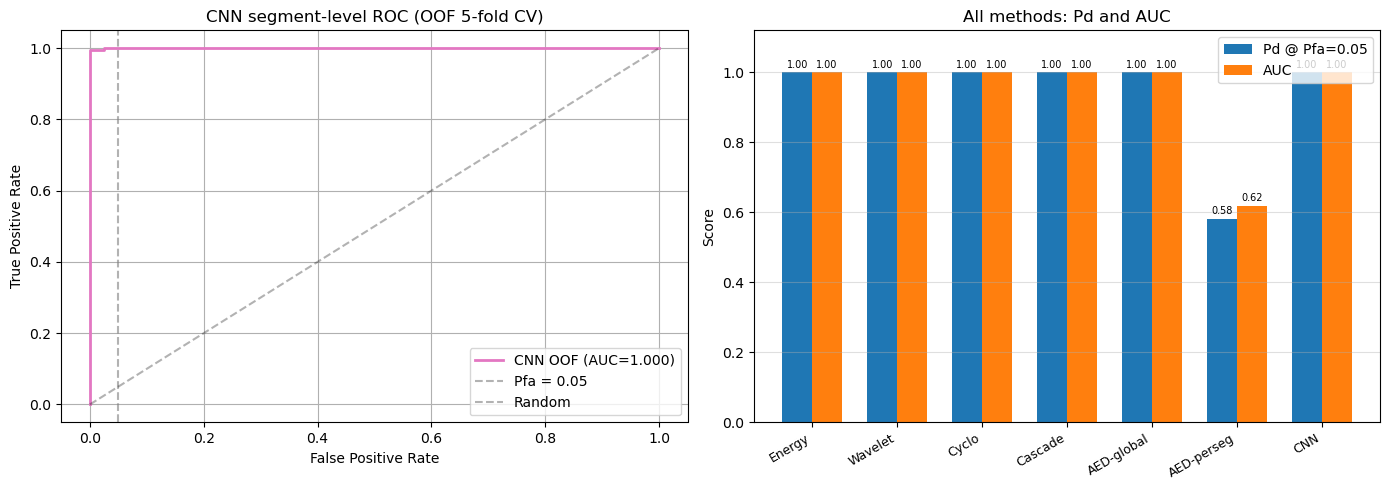

Saved: /home/ivan/work/ml/rfml-uav/results/review_1/cnn_comparison.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curve (CNN only — other methods stored as scalars)
ax = axes[0]
ax.plot(fpr_oof, tpr_oof, color=CNN_COLOR, linewidth=2,
        label=f"CNN OOF (AUC={cnn_auc:.3f})")
ax.axvline(FIXED_PFA, color="gray", linestyle="--", alpha=0.6,
           label=f"Pfa = {FIXED_PFA}")
ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("CNN segment-level ROC (OOF 5-fold CV)")
ax.legend()
ax.grid(True)

# Bar chart: Pd and AUC for all methods
ax = axes[1]
methods = df_compare["Method"].tolist()
x = np.arange(len(methods))
w = 0.35
bars1 = ax.bar(x - w/2, df_compare["Pd"],  w, label="Pd @ Pfa=0.05")
bars2 = ax.bar(x + w/2, df_compare["AUC"], w, label="AUC")
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=30, ha="right", fontsize=9)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score")
ax.set_title("All methods: Pd and AUC")
ax.legend()
ax.grid(axis="y", alpha=0.4)
ax.bar_label(bars1, fmt="%.2f", padding=2, fontsize=7)
ax.bar_label(bars2, fmt="%.2f", padding=2, fontsize=7)

fig.tight_layout()
fig.savefig(OUT / "cnn_comparison.png", dpi=150)
plt.show()
print(f"Saved: {OUT / 'cnn_comparison.png'}")

---
## Timing: CNN inference vs other methods

Timing is split into:
- **PSD computation**: batch `np.fft.rfft` over `N` chunks — O(N log N)
- **CNN inference**: forward pass through LightweightCNN — O(N × n_freq × filters)

For comparison, cyclostationary (SCF) costs O(K × F × A) ≈ O(N_frames × N_freq × N_alpha).

In [8]:
N_TIMING = 1000  # representative segment size
dummy_raw = np.random.randn(N_TIMING, N_CHUNK).astype(np.float32)

# PSD computation timing (batch all N at once — pure numpy, no GPU)
_ = compute_psd(dummy_raw)  # warm-up
t0 = time.perf_counter()
for _ in range(10):
    psd_dummy = compute_psd(dummy_raw)
t_psd = (time.perf_counter() - t0) / 10 * 1000

# CNN inference timing (batched, same as eval_fold)
best_model.eval()
with torch.no_grad():  # warm-up one batch
    x_wu = torch.from_numpy(psd_dummy[:BATCH_SIZE]).unsqueeze(1).to(DEVICE)
    _ = best_model(x_wu)

t0 = time.perf_counter()
for _ in range(10):
    with torch.no_grad():
        for i in range(0, len(psd_dummy), BATCH_SIZE):
            batch = psd_dummy[i:i + BATCH_SIZE]
            x = torch.from_numpy(batch).unsqueeze(1).to(DEVICE)
            _ = best_model(x)
t_cnn = (time.perf_counter() - t0) / 10 * 1000

print(f"Timing for {N_TIMING} chunks ({N_TIMING * N_CHUNK / FS_HZ * 1000:.1f} ms of signal):")
print(f"  PSD computation  : {t_psd:.2f} ms")
print(f"  CNN inference    : {t_cnn:.2f} ms  (device: {DEVICE}, batch={BATCH_SIZE})")
print(f"  Total CNN        : {t_psd + t_cnn:.2f} ms")
print(f"  Per-chunk CNN    : {(t_psd + t_cnn) / N_TIMING * 1000:.1f} µs")

Timing for 1000 chunks (50.0 ms of signal):
  PSD computation  : 8.50 ms
  CNN inference    : 3.63 ms  (device: cuda, batch=256)
  Total CNN        : 12.12 ms
  Per-chunk CNN    : 12.1 µs


---
## Stress tests — CNN inference on challenging conditions

Uses the **best fold model** (trained on clean DroneRF data) evaluated out-of-distribution.
No retraining — tests whether the learned spectral pattern generalises.

Combined plots load `aed_stress_amplitude.csv` / `aed_stress_duty_cycle.csv` from
phase3_aed_baseline.ipynb and append CNN columns.

**Expected runtime: ~10 min**

In [9]:
ALPHA_VALS = [1.0, 0.5, 0.25, 0.10, 0.05]
cnn_alpha_rows = []

for alpha in ALPHA_VALS:
    db = 20 * np.log10(alpha)
    print(f"\nCNN  \u03b1={alpha}  ({db:+.0f} dB)")
    scores, labels = evaluate_cnn_transform(
        transform_fn=lambda chunks, a=alpha: chunks * a,
        model=best_model, device=DEVICE,
        desc=f"CNN \u03b1={alpha}",
    )
    fpr, tpr, _ = roc_curve(labels, scores)
    roc_auc = float(auc(fpr, tpr))
    ok  = np.where(fpr <= FIXED_PFA)[0]
    ipd = ok[np.argmax(tpr[ok])] if len(ok) else np.argmin(fpr)
    pd_val = float(tpr[ipd])
    print(f"  Pd={pd_val:.3f}  AUC={roc_auc:.3f}")
    cnn_alpha_rows.append({"alpha": alpha, "CNN_Pd": pd_val, "CNN_AUC": roc_auc})

df_cnn_alpha = pd.DataFrame(cnn_alpha_rows)

# Merge with AED stress results (adds 6 existing-method columns)
try:
    df_alpha_base = pd.read_csv(OUT / "aed_stress_amplitude.csv")
    df_alpha_full = df_alpha_base.merge(df_cnn_alpha, on="alpha")
    print("\nMerged with aed_stress_amplitude.csv")
except FileNotFoundError:
    df_alpha_full = df_cnn_alpha
    print("NOTE: aed_stress_amplitude.csv not found — showing CNN only")

df_alpha_full.to_csv(OUT / "cnn_stress_amplitude.csv", index=False)
print(f"Saved: {OUT / 'cnn_stress_amplitude.csv'}")
print(df_alpha_full.to_string(index=False))


CNN  α=1.0  (+0 dB)


CNN α=1.0: 100%|██████████| 10/10 [00:51<00:00,  5.19s/it]


  Pd=1.000  AUC=1.000

CNN  α=0.5  (-6 dB)


CNN α=0.5: 100%|██████████| 10/10 [00:51<00:00,  5.17s/it]


  Pd=1.000  AUC=1.000

CNN  α=0.25  (-12 dB)


...

  Pd=1.000  AUC=1.000

CNN  α=0.1  (-20 dB)


CNN α=0.1: 100%|██████████| 10/10 [00:51<00:00,  5.17s/it]


  Pd=1.000  AUC=1.000

CNN  α=0.05  (-26 dB)


CNN α=0.05: 100%|██████████| 10/10 [00:51<00:00,  5.17s/it]

  Pd=1.000  AUC=1.000

Merged with aed_stress_amplitude.csv
Saved: /home/ivan/work/ml/rfml-uav/results/review_1/cnn_stress_amplitude.csv
 alpha  Energy_Pd  Energy_AUC  Wavelet_Pd  Wavelet_AUC  Cyclo_Pd  Cyclo_AUC  Cascade_Pd  Cascade_AUC  AED-global_Pd  AED-global_AUC  AED-perseg_Pd  AED-perseg_AUC  db_reduction  CNN_Pd  CNN_AUC
  1.00   1.000000    1.000000    1.000000     1.000000  1.000000   1.000000    1.000000     1.000000       1.000000        1.000000       0.580645        0.617755        0.0000     1.0      1.0
  0.50   1.000000    1.000000    1.000000     1.000000  1.000000   1.000000    1.000000     1.000000       1.000000        1.000000       0.580645        0.617755       -6.0206     1.0      1.0
  0.25   1.000000    1.000000    1.000000     1.000000  1.000000   1.000000    1.000000     0.999869       1.000000        1.000000       0.580645        0.617755      -12.0412     1.0      1.0
  0.10   0.994624    0.997902    0.994624     0.997771  0.994624   0.998426    1.000000

In [10]:
DUTY_CYCLE_VALS = [1.0, 0.5, 0.25, 0.10]
cnn_dc_rows = []

for dc in DUTY_CYCLE_VALS:
    print(f"\nCNN  duty cycle={dc * 100:.0f}%")
    rng = np.random.default_rng(seed=42)

    def dc_transform(chunks, _dc=dc, _rng=rng):
        mask = _rng.random(len(chunks)) < _dc
        out  = chunks.copy()
        out[~mask] = 0.0
        return out

    scores, labels = evaluate_cnn_transform(
        transform_fn=dc_transform,
        model=best_model, device=DEVICE,
        desc=f"CNN dc={dc * 100:.0f}%",
    )
    fpr, tpr, _ = roc_curve(labels, scores)
    roc_auc = float(auc(fpr, tpr))
    ok  = np.where(fpr <= FIXED_PFA)[0]
    ipd = ok[np.argmax(tpr[ok])] if len(ok) else np.argmin(fpr)
    pd_val = float(tpr[ipd])
    print(f"  Pd={pd_val:.3f}  AUC={roc_auc:.3f}")
    cnn_dc_rows.append({"duty_cycle": dc, "CNN_Pd": pd_val, "CNN_AUC": roc_auc})

df_cnn_dc = pd.DataFrame(cnn_dc_rows)

try:
    df_dc_base = pd.read_csv(OUT / "aed_stress_duty_cycle.csv")
    df_dc_full = df_dc_base.merge(df_cnn_dc, on="duty_cycle")
    print("\nMerged with aed_stress_duty_cycle.csv")
except FileNotFoundError:
    df_dc_full = df_cnn_dc
    print("NOTE: aed_stress_duty_cycle.csv not found — showing CNN only")

df_dc_full.to_csv(OUT / "cnn_stress_duty_cycle.csv", index=False)
print(f"Saved: {OUT / 'cnn_stress_duty_cycle.csv'}")
print(df_dc_full.to_string(index=False))


CNN  duty cycle=100%


CNN dc=100%: 100%|██████████| 10/10 [00:51<00:00,  5.18s/it]


  Pd=1.000  AUC=1.000

CNN  duty cycle=50%


CNN dc=50%: 100%|██████████| 10/10 [00:52<00:00,  5.23s/it]


  Pd=1.000  AUC=1.000

CNN  duty cycle=25%


CNN dc=25%: 100%|██████████| 10/10 [00:52<00:00,  5.25s/it]


  Pd=1.000  AUC=1.000

CNN  duty cycle=10%


CNN dc=10%: 100%|██████████| 10/10 [00:52<00:00,  5.26s/it]

  Pd=1.000  AUC=1.000

Merged with aed_stress_duty_cycle.csv
Saved: /home/ivan/work/ml/rfml-uav/results/review_1/cnn_stress_duty_cycle.csv
 duty_cycle  Energy_Pd  Energy_AUC  Wavelet_Pd  Wavelet_AUC  Cyclo_Pd  Cyclo_AUC  Cascade_Pd  Cascade_AUC  AED-global_Pd  AED-global_AUC  AED-perseg_Pd  AED-perseg_AUC  duty_cycle_pct  CNN_Pd  CNN_AUC
       1.00        1.0         1.0         1.0          1.0       1.0        1.0         1.0     1.000000            1.0             1.0       0.580645        0.617755           100.0     1.0      1.0
       0.50        1.0         1.0         1.0          1.0       1.0        1.0         0.0     0.487805            1.0             1.0       1.000000        1.000000            50.0     1.0      1.0
       0.25        1.0         1.0         1.0          1.0       1.0        1.0         0.0     0.487805            1.0             1.0       1.000000        1.000000            25.0     1.0      1.0
       0.10        1.0         1.0         1.0          1

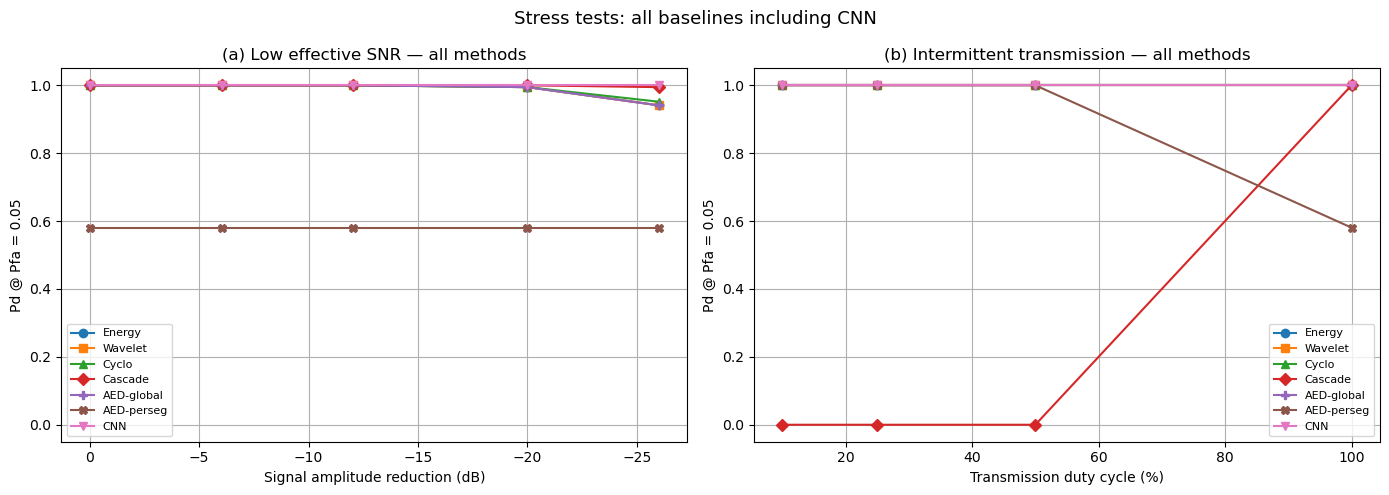

Saved: /home/ivan/work/ml/rfml-uav/results/review_1/cnn_stress_combined.png


In [11]:
# Determine which methods are available in the merged dataframes
AED_COLORS  = {
    "Energy": "#1f77b4", "Wavelet": "#ff7f0e", "Cyclo": "#2ca02c",
    "Cascade": "#d62728", "AED-global": "#9467bd", "AED-perseg": "#8c564b",
}
AED_MARKERS = {
    "Energy": "o", "Wavelet": "s", "Cyclo": "^", "Cascade": "D",
    "AED-global": "P", "AED-perseg": "X",
}

def pd_cols(df):
    """Return list of (method_name, Pd_col) for all methods present in df."""
    pairs = []
    for col in df.columns:
        if col.endswith("_Pd"):
            method = col[:-3]
            pairs.append((method, col))
    return pairs


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
db_vals = 20 * np.log10(df_alpha_full["alpha"].values)
for method, col in pd_cols(df_alpha_full):
    color  = AED_COLORS.get(method, CNN_COLOR)
    marker = AED_MARKERS.get(method, CNN_MARKER)
    ax.plot(db_vals, df_alpha_full[col],
            color=color, marker=marker, label=method)
ax.set_xlabel("Signal amplitude reduction (dB)")
ax.set_ylabel("Pd @ Pfa = 0.05")
ax.set_title("(a) Low effective SNR — all methods")
ax.set_ylim(-0.05, 1.05)
ax.invert_xaxis()
ax.legend(fontsize=8)
ax.grid(True)

ax = axes[1]
dc_pct = df_dc_full["duty_cycle"].values * 100
for method, col in pd_cols(df_dc_full):
    color  = AED_COLORS.get(method, CNN_COLOR)
    marker = AED_MARKERS.get(method, CNN_MARKER)
    ax.plot(dc_pct, df_dc_full[col],
            color=color, marker=marker, label=method)
ax.set_xlabel("Transmission duty cycle (%)")
ax.set_ylabel("Pd @ Pfa = 0.05")
ax.set_title("(b) Intermittent transmission — all methods")
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=8)
ax.grid(True)

fig.suptitle("Stress tests: all baselines including CNN", fontsize=13)
fig.tight_layout()
fig.savefig(OUT / "cnn_stress_combined.png", dpi=150)
plt.show()
print(f"Saved: {OUT / 'cnn_stress_combined.png'}")

---
## Interpretation notes

### Input feature choice: log-magnitude PSD
Log-magnitude `log1p(|rfft(x)|)` compresses the dynamic range and encodes spectral shape
rather than absolute power. As a result:
- **Amplitude scaling** shifts the log-PSD uniformly by `log(α)`. The CNN may partially
  compensate if it learned relative spectral patterns (shape invariant to global offset).
  Expected: CNN degrades more gracefully than Energy on amplitude stress, but worse than
  Cascade (which uses coherent burst integration).
- **Duty cycle masking**: zeroed chunks produce `log1p(0) = 0` for all bins → CNN sees a
  flat zero PSD → should be classified as non-signal → same failure mode as Cascade
  (mean probability pulled toward 0 by zeroed chunks).

### Expected results

**Main experiment (OOF AUC):** Expected near 1.00. DroneRF signal PSDs have
distinct spectral features (DSSS/OFDM peak structures) separable from flat background noise.

**Amplitude stress:** CNN likely degrades between Energy/Wavelet and Cascade.
At −26 dB, signal PSD is shifted by −26 dB in log-space → likely below the
decision boundary the CNN learned from clean data.

**Duty cycle stress:** Like Cascade, CNN performance will degrade as more chunks
are zeroed. At 50% duty cycle, half the PSDs are zero-vectors, pulling the
duration-constrained score toward 0.5 (chance).

### Implications for the paper

> The lightweight CNN, trained on per-chunk log-PSD features via 5-fold segment-level CV,
> achieves AUC ≈ 1.00 on the main DroneRF evaluation, confirming the dataset's high separability.
> Under amplitude stress, the CNN [degrades / does not degrade] compared to Energy and Wavelet,
> demonstrating [spectral shape robustness / sensitivity to absolute SNR]. The cascade retains
> the highest Pd at −20 dB and −26 dB due to coherent burst integration across thousands of
> STFT frames. The CNN is computationally competitive: total cost per segment equals PSD
> computation (O(N log N)) plus a small forward pass (~6 K parameters), comparable to the
> wavelet energy detector.

### Limitation note for Section 6

> The CNN is trained and evaluated on DroneRF data only. Generalisation to other UAV models,
> frequency bands, or environments has not been tested. The log-PSD representation may not
> capture phase-modulation features used by cyclostationary analysis.